In [1]:
import os 
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path=r"C:\Users\Pc\Documents\Tese\written"

In [3]:
excel_file="windowed_results_f.xlsx"
# Read Excel Files 
path_excel = os.path.join(path, excel_file)
data = pd.read_excel(path_excel)

print(data.head())


   ID  Balancing    TP   FP    FN    TN
0   6        1.0   906   67  2150  2978
1   6        1.0   630   48  2426  2997
2   6        1.0  1651  180  1405  2865
3   6        1.0  1629  172  1427  2873
4   6        1.0  1809  340  1247  2405


In [4]:
balance=[0.5,1,2,3]

for b in balance:
    data_b = data[data['Balancing'] == b]
    print(f"Balance: {b}")
    print(data_b.head())
    

Balance: 0.5
    ID  Balancing    TP    FP    FN    TN
82  12        0.5  1195  6011  1841    49
83  12        0.5  1202  6010  1834    50
84  12        0.5  1207   125  1829  5935
85  12        0.5   945    81  2091  5979
86  12        0.5  1523   242  1513  5818
Balance: 1
   ID  Balancing    TP   FP    FN    TN
0   6        1.0   906   67  2150  2978
1   6        1.0   630   48  2426  2997
2   6        1.0  1651  180  1405  2865
3   6        1.0  1629  172  1427  2873
4   6        1.0  1809  340  1247  2405
Balance: 2
    ID  Balancing   TP  FP   FN   TN
29   8        2.0  250  10  795  515
30   8        2.0  783  65  263  460
31   8        2.0  749  56  297  469
32   8        2.0  599  25  447  500
33   8        2.0  520  15  526  510
Balance: 3
    ID  Balancing    TP   FP    FN    TN
58   2        3.0  1340   59  1698   949
59   2        3.0  1910  331  1128   677
60   2        3.0   557    6  2479  1004
61   2        3.0  1077   32  1962   975
62   2        3.0   887   33  2149 

In [5]:
def compute_classification_metrics(df):
    df = df.copy()  # Avoid modifying original

    df["Accuracy"] = (df["TP"] + df["TN"]) / (df["TP"] + df["FP"] + df["FN"] + df["TN"])
    df["Precision"] = df["TP"] / (df["TP"] + df["FP"])
    df["Recall"] = df["TP"] / (df["TP"] + df["FN"])
    # df["Specificity"] = df["TN"] / (df["TN"] + df["FP"])
    df["F1"] = 2 * df["Precision"] * df["Recall"] / (df["Precision"] + df["Recall"])

    return df

data_metrics = compute_classification_metrics(data)
# Show by balance
balance = [0.5, 1, 2, 3]
for b in balance:
    data_b = data_metrics[data_metrics['Balancing'] == b]
    print(data_b)

     ID  Balancing    TP    FP    FN    TN  Accuracy  Precision    Recall  \
82   12        0.5  1195  6011  1841    49  0.136763   0.165834  0.393610   
83   12        0.5  1202  6010  1834    50  0.137643   0.166667  0.395916   
84   12        0.5  1207   125  1829  5935  0.785180   0.906156  0.397563   
85   12        0.5   945    81  2091  5979  0.761214   0.921053  0.311265   
86   12        0.5  1523   242  1513  5818  0.807058   0.862890  0.501647   
87   12        0.5  1592   441  1444  5619  0.792766   0.783079  0.524374   
88   12        0.5  1680   979  1356  5081  0.743294   0.631816  0.553360   
89   12        0.5     7     5  3029  6055  0.666447   0.583333  0.002306   
90   12        0.5  1839   804  1197  5256  0.780013   0.695800  0.605731   
91   12        0.5    89     2  2947  6058  0.675792   0.978022  0.029315   
92   12        0.5  1513   406  1523  5654  0.787929   0.788431  0.498353   
93   12        0.5   643    75  2393  5985  0.728672   0.895543  0.211792   

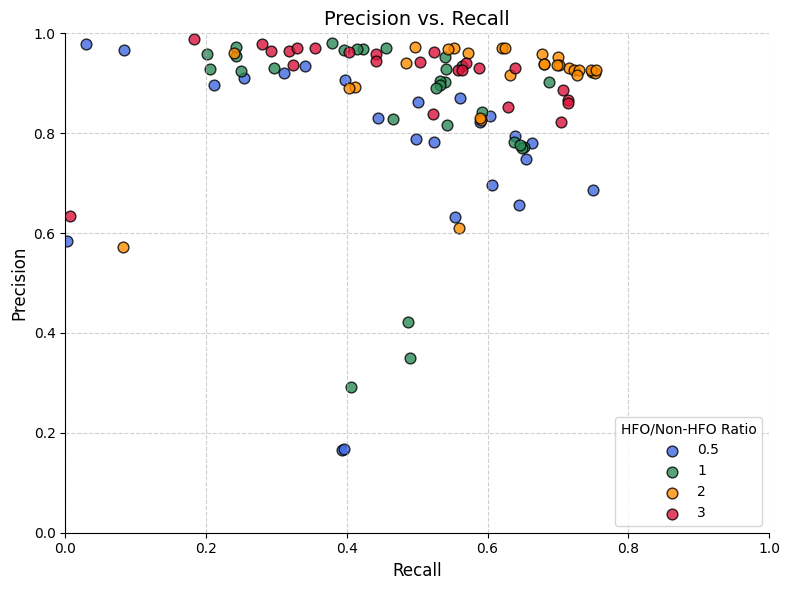

In [24]:
# Make sure 'data_metrics' includes 'Precision', 'Recall', and 'Balancing'
colors = {
    0.5: "royalblue",
    1: "seagreen",
    2: "darkorange",
    3: "crimson"
}

plt.figure(figsize=(8, 6))

# Plot each balancing group
balance = [0.5, 1, 2, 3]
for b in sorted(balance):
    group = data_metrics[data_metrics['Balancing'] == b]
    plt.scatter(group["Recall"], group["Precision"],
                label=f"{b}",
                color=colors.get(b, 'gray'),
                alpha=0.8,
                s=60, edgecolors='black')

# Aesthetics
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision vs. Recall", fontsize=14)
plt.legend(title="HFO/Non-HFO Ratio", fontsize=10,loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

# Optional: remove top/right spines
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
    
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

def plot_whiskers(df, balances, metrics, colors=None,balance_colors=None):
    if colors is None:
        colors = {
            "Precision": "royalblue",
            "Recall": "seagreen",
            "F1": "darkorange"
        }

    # Ensure metrics is a list
    metrics = metrics if isinstance(metrics, list) else [metrics]
    width = 1 # Width of each boxplot
    spacing = 1  # Space between groups

    fig, ax = plt.subplots(figsize=(10, 6))

    positions = []
    data = []
    plot_colors = []
    xticks = []
    xtick_labels = []

    for i, b in enumerate(sorted(balances)):
        base_pos = i * (len(metrics) + 1)  # Leave space between groups
        for j, metric in enumerate(metrics):
            vals = df[df['Balancing'] == b][metric].dropna().values
            pos = base_pos + j * width
            data.append(vals)
            positions.append(pos)
            plot_colors.append(colors.get(metric, "gray"))

        # Center tick between the metric boxes
        xticks.append(base_pos + (len(metrics) - 1) * width / 2)
        xtick_labels.append(str(b))
        
        # Add background shading
        shade_color = balance_colors.get(b, "lightgray") if balance_colors else "lightgray"
        ax.axvspan(base_pos - 0.7, base_pos + len(metrics) * width - 0.3, color=shade_color, alpha=0.2)

    # Draw boxplots
    for d, p, c in zip(data, positions, plot_colors):
        bplot = ax.boxplot(d, positions=[p], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(c)

    # Aesthetics
    ax.tick_params(axis='y', which='major', labelsize=12)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels,fontsize=12)
    ax.set_xlabel("HFO/Non-HFO Ratio", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Precision, Recall, and F1 Score across Balancing Conditions", fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, len(balances) * (len(metrics) + 1)-1)

    
    # Optional: remove top/right spines
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)
    # Legend
    legend_handles = [Patch(facecolor=colors[m], label=m) for m in metrics]
    ax.legend(handles=legend_handles, fontsize=12, loc='upper left',bbox_to_anchor=(1.01, 0.5))

    plt.tight_layout()
    plt.show()
    return fig,ax


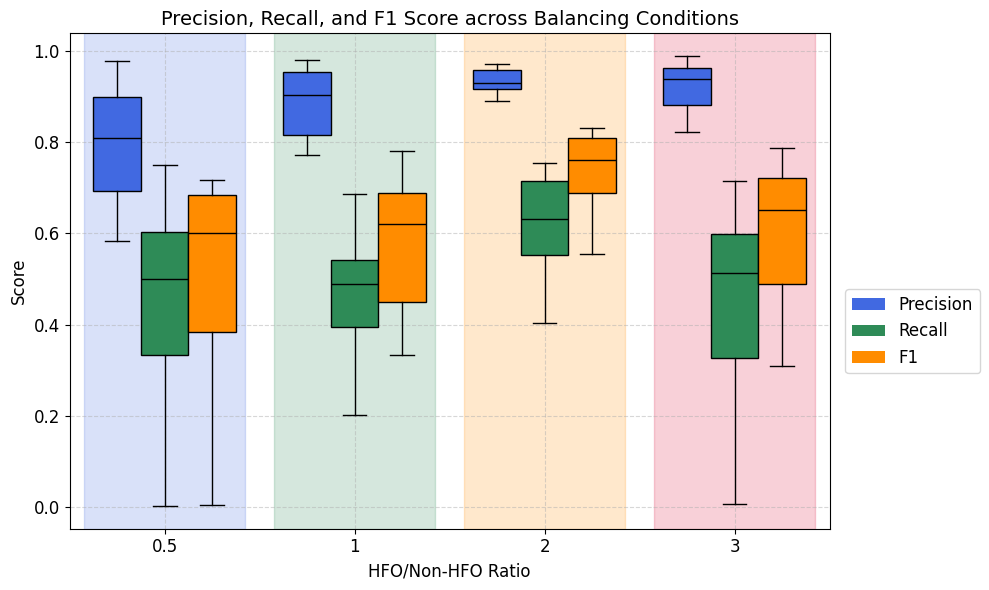

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Precision, Recall, and F1 Score across Balancing Conditions'}, xlabel='HFO/Non-HFO Ratio', ylabel='Score'>)

In [8]:
balances= [0.5, 1, 2, 3]
plot_whiskers(data_metrics, balances=balances, metrics=["Precision", "Recall", "F1"],balance_colors=colors)

In [13]:
from scipy.stats import ttest_ind
from itertools import combinations
import statsmodels.stats.multitest as smm

def test_groups(df, balances, alpha=0.05):
    groups = {b: df[df['Balancing'] == b]['F1'].dropna() for b in balances}
    results = []

    # Generate all pairs of group combinations
    for b1, b2 in combinations(balances, 2):
        g1 = groups[b1]
        g2 = groups[b2]

        # Perform independent t-test (assumes normality)
        stat, p = ttest_ind(g1, g2, equal_var=False)  # Welch's t-test is safer
        results.append((b1, b2, p))

    # Correct p-values for multiple comparisons
    p_values = [r[2] for r in results]
    reject, pvals_corrected, _, _ = smm.multipletests(p_values, alpha=alpha, method='bonferroni')

    # Print results
    for i, (b1, b2, raw_p) in enumerate(results):
        sig = "✅" if reject[i] else "❌"
        print(f"{sig} {b1} vs {b2}: raw p = {raw_p:.4g}, corrected p = {pvals_corrected[i]:.4g}")

test_groups(data_metrics, balances=balances, alpha=0.05)

❌ 0.5 vs 1: raw p = 0.2048, corrected p = 1
✅ 0.5 vs 2: raw p = 0.0004687, corrected p = 0.002812
❌ 0.5 vs 3: raw p = 0.1308, corrected p = 0.7848
✅ 1 vs 2: raw p = 0.0007674, corrected p = 0.004604
❌ 1 vs 3: raw p = 0.6178, corrected p = 1
❌ 2 vs 3: raw p = 0.01844, corrected p = 0.1106


In [16]:
all_metrics = set()
# Prepare table
rows = []

for b in balances:
    row = {"Balance": b}

    for metric in ["Precision", "Recall", "F1"]:
        vals = data_metrics[data_metrics['Balancing'] == b][metric].dropna().values
        median = np.median(vals)
        peak= np.max(vals)
        std = np.std(vals)  # ddof=1 for sample std deviation
        row[metric] = f"{median:.2f} ± {std:.2f}"
        row[f"{metric}_peak"] = f"{peak:.2f}"
    rows.append(row)
# Create DataFrame
df = pd.DataFrame(rows)
df.set_index("Balance", inplace=True)

# Display the table
print(df.to_string())

df.to_excel("summary_stats.xlsx", index=False)

           Precision Precision_peak       Recall Recall_peak           F1 F1_peak
Balance                                                                          
0.5      0.81 ± 0.21           0.98  0.50 ± 0.20        0.75  0.60 ± 0.22    0.72
1.0      0.90 ± 0.18           0.98  0.49 ± 0.14        0.69  0.62 ± 0.14    0.78
2.0      0.93 ± 0.09           0.97  0.63 ± 0.16        0.75  0.76 ± 0.15    0.83
3.0      0.94 ± 0.07           0.99  0.51 ± 0.18        0.71  0.65 ± 0.18    0.79


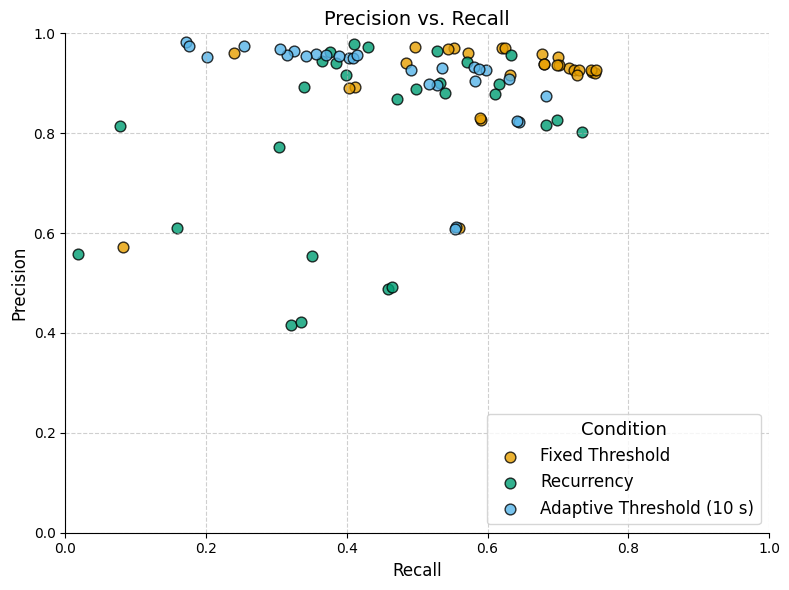

In [25]:
# Make sure 'data_metrics' includes 'Precision', 'Recall', and 'Balancing'
colors = {
    2: "#E69F00",     # orange (Fixed Threshold)
    20: "#56B4E9",    # sky blue (Adaptive Threshold)
    13: "#009E73"     # teal/green (Recurrency)
}

labels= {
    2: "Fixed Threshold",
    20: "Adaptive Threshold (10 s)", 
    13: "Recurrency"}


plt.figure(figsize=(8, 6))

# Plot each balancing group
balance = [ 2, 20, 13 ]
for b in sorted(balance):
    group = data_metrics[data_metrics['Balancing'] == b]
    plt.scatter(group["Recall"], group["Precision"],
                label=labels[b],
                color=colors.get(b, 'gray'),
                alpha=0.8,
                s=60, edgecolors='black')

# Aesthetics
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision vs. Recall", fontsize=14)
plt.legend(title="Condition",  title_fontsize=13,fontsize=12,loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Optional: remove top/right spines
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
    
plt.tight_layout()
plt.show()

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

def plot_whiskers_2(df, balances, metrics, colors=None,balance_colors=None):
    if colors is None:
        colors = {
            "Precision": "royalblue",
            "Recall": "seagreen",
            "F1": "darkorange"
        }

    labels= {
        2: "Fixed Threshold",
        20: "Adaptive Threshold (10 s)", 
        13: "Recurrency"}

    # Ensure metrics is a list
    metrics = metrics if isinstance(metrics, list) else [metrics]
    width = 1 # Width of each boxplot
    spacing = 1  # Space between groups

    fig, ax = plt.subplots(figsize=(10, 6))

    positions = []
    data = []
    plot_colors = []
    xticks = []
    xtick_labels = []

    for i, b in enumerate(sorted(balances)):
        base_pos = i * (len(metrics) + 1)  # Leave space between groups
        for j, metric in enumerate(metrics):
            vals = df[df['Balancing'] == b][metric].dropna().values
            pos = base_pos + j * width
            data.append(vals)
            positions.append(pos)
            plot_colors.append(colors.get(metric, "gray"))

        # Center tick between the metric boxes
        xticks.append(base_pos + (len(metrics) - 1) * width / 2)
        xtick_labels.append(labels[b])
        
        # Add background shading
        shade_color = balance_colors.get(b, "lightgray") if balance_colors else "lightgray"
        ax.axvspan(base_pos - 0.7, base_pos + len(metrics) * width - 0.3, color=shade_color, alpha=0.2)

    # Draw boxplots
    for d, p, c in zip(data, positions, plot_colors):
        bplot = ax.boxplot(d, positions=[p], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(c)

    # Aesthetics
    ax.tick_params(axis='y', which='major', labelsize=12)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels,fontsize=12)
    ax.set_xlabel("Condition", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Precision, Recall, and F1 Score across Balancing Conditions", fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, len(balances) * (len(metrics) + 1)-1)

    # Legend
    legend_handles = [Patch(facecolor=colors[m], label=m) for m in metrics]
    ax.legend(handles=legend_handles, fontsize=12, loc='upper left',bbox_to_anchor=(1.01, 0.5))
            
    # Optional: remove top/right spines
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()
    return fig,ax


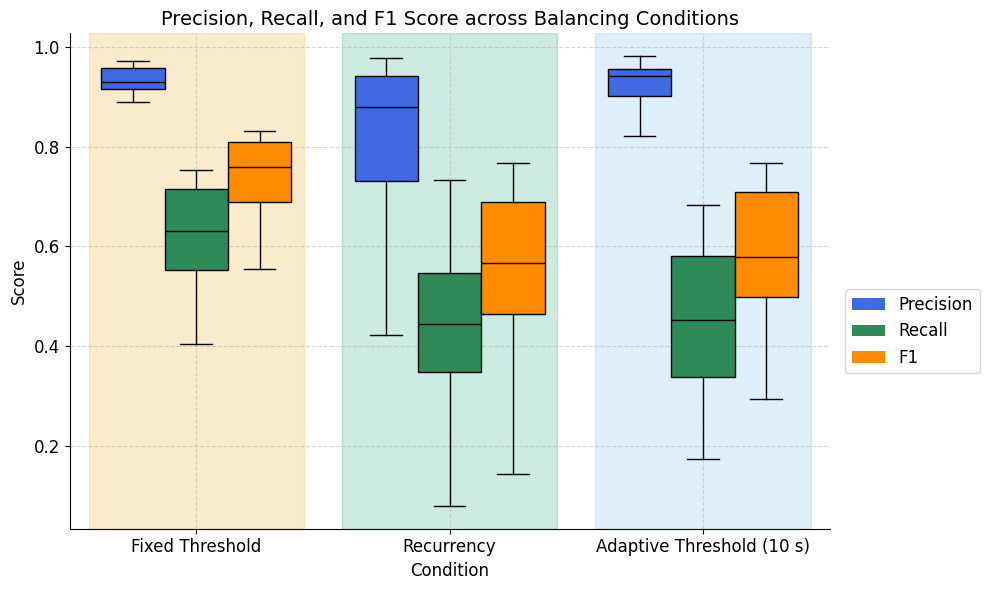

In [ ]:
fig,ax=plot_whiskers_2(data_metrics, balances=balance, metrics=["Precision","Recall","F1"], colors=None,balance_colors=colors)

In [20]:
all_metrics = set()
# Prepare table
rows = []

for b in balance:
    row = {"Balance": b}

    for metric in ["Precision", "Recall", "F1"]:
        vals = data_metrics[data_metrics['Balancing'] == b][metric].dropna().values
        median = np.median(vals)
        peak= np.max(vals)
        std = np.std(vals)  # ddof=1 for sample std deviation
        row[metric] = f"{median:.2f} ± {std:.2f}"
        row[f"{metric}_peak"] = f"{peak:.2f}"
    rows.append(row)
# Create DataFrame
df = pd.DataFrame(rows)
df.set_index("Balance", inplace=True)

# Display the table
print(df.to_string())

df.to_excel("summary_stats_adapt_srnn.xlsx", index=False)

           Precision Precision_peak       Recall Recall_peak           F1 F1_peak
Balance                                                                          
2        0.93 ± 0.09           0.97  0.63 ± 0.16        0.75  0.76 ± 0.15    0.83
20       0.94 ± 0.09           0.98  0.45 ± 0.15        0.68  0.58 ± 0.13    0.77
13       0.88 ± 0.18           0.98  0.44 ± 0.17        0.73  0.57 ± 0.18    0.77


In [21]:
test_groups(data_metrics, balances=balance, alpha=0.05)
print(balance)

✅ 2 vs 20: raw p = 0.001053, corrected p = 0.003159
✅ 2 vs 13: raw p = 0.0005945, corrected p = 0.001784
❌ 20 vs 13: raw p = 0.4529, corrected p = 1
[2, 20, 13]
